In [1]:
!pip install xgboost

In [2]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score

# XGBoost
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22.0,59000.0,RENT,123.0,PERSONAL,D,35000.0,16.02,1.0,0.59,Y,3.0
1,21.0,9600.0,OWN,5.0,EDUCATION,B,1000.0,11.14,0.0,0.10,N,2.0
2,25.0,9600.0,MORTGAGE,1.0,MEDICAL,C,5500.0,12.87,1.0,0.57,N,3.0
3,23.0,65500.0,RENT,4.0,MEDICAL,C,35000.0,15.23,1.0,0.53,N,2.0
4,24.0,54400.0,RENT,8.0,MEDICAL,C,35000.0,14.27,1.0,0.55,Y,4.0


In [4]:
# Removing empty rows completely 

df = df.dropna(how='all')

In [5]:
# Number of rows and columns

df.shape

(5000, 12)

In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  5000 non-null   float64
 1   person_income               5000 non-null   float64
 2   person_home_ownership       5000 non-null   object 
 3   person_emp_length           4791 non-null   float64
 4   loan_intent                 5000 non-null   object 
 5   loan_grade                  5000 non-null   object 
 6   loan_amnt                   5000 non-null   float64
 7   loan_int_rate               4535 non-null   float64
 8   loan_status                 5000 non-null   float64
 9   loan_percent_income         5000 non-null   float64
 10  cb_person_default_on_file   5000 non-null   object 
 11  cb_person_cred_hist_length  5000 non-null   float64
dtypes: float64(8), object(4)
memory usage: 507.8+ KB


In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,5000.000000,5000.000000,4791.000000,5000.000000,4535.000000,5000.000000,5000.000000,5000.00000
mean,23.579800,49509.141400,3.708829,8478.630000,11.215244,0.306600,0.185228,2.98960
std,3.475809,36813.181007,3.720418,7182.711611,3.208416,0.461128,0.125088,0.82026
min,20.000000,9600.000000,0.000000,500.000000,5.420000,0.000000,0.010000,2.00000
25%,22.000000,30000.000000,1.000000,3200.000000,8.490000,0.000000,0.090000,2.00000
50%,23.000000,39000.000000,3.000000,5000.000000,11.120000,0.000000,0.150000,3.00000
75%,25.000000,55014.000000,6.000000,12000.000000,13.490000,1.000000,0.260000,4.00000
max,144.000000,500000.000000,123.000000,35000.000000,21.740000,1.000000,0.830000,4.00000


In [9]:
df.isnull().sum()

person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             209
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_int_rate                 465
loan_status                     0
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Filling missing values in person_emp_length using Median

df['person_emp_length'].fillna(
    df['person_emp_length'].median(),
    inplace=True
)

In [12]:
# Filling missing values in loan_int_rate using Mean

df['loan_int_rate'].fillna(
    df['loan_int_rate'].mean(),
    inplace=True
)

In [13]:
# Verifying missing values again

df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [14]:
# Checking numerical columns for outlier analysis

num_cols = ['person_age',
            'person_income',
            'person_emp_length',
            'loan_amnt',
            'loan_int_rate',
            'loan_percent_income',
            'cb_person_cred_hist_length']

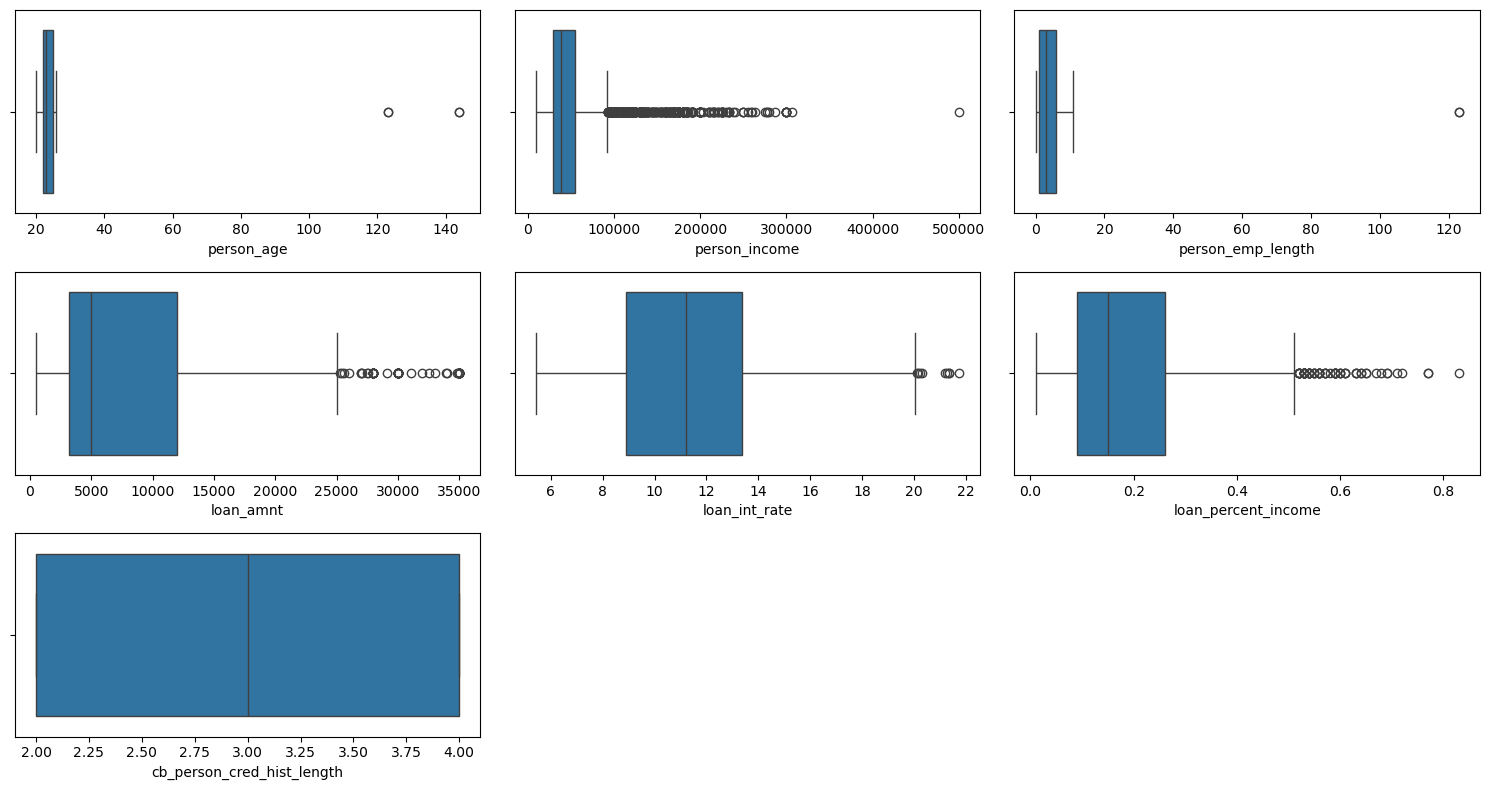

In [15]:
# Showing outliers using boxplots

plt.figure(figsize=(15,8))

for i,col in enumerate(num_cols,1):

    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])

plt.tight_layout()
plt.show()

In [16]:
# Detecting outliers using IQR method

for col in num_cols:

    # Calculate First Quartile (Q1)
    Q1 = df[col].quantile(0.25)

    # Calculate Third Quartile (Q3)
    Q3 = df[col].quantile(0.75)

    # Calculate Interquartile Range
    IQR = Q3 - Q1

    # Define lower boundary
    lower_bound = Q1 - 1.5*IQR

    # Define upper boundary
    upper_bound = Q3 + 1.5*IQR

    # Count number of outliers
    outliers = ((df[col] < lower_bound) |
                (df[col] > upper_bound)).sum()

    # Print outlier count
    print(col,":",outliers)

person_age : 4
person_income : 440
person_emp_length : 2
loan_amnt : 70
loan_int_rate : 9
loan_percent_income : 71
cb_person_cred_hist_length : 0


In [17]:
# Removing unrealistic ages

df = df[df['person_age'] <= 100]

# Removing unrealistic employment length

df = df[df['person_emp_length'] <= 50]

In [18]:
# Average Interest Rate by Loan Grade

df.groupby('loan_grade')['loan_int_rate'].mean()

loan_grade
A     7.718659
B    10.986531
C    13.237218
D    15.040054
E    16.540401
F    17.052665
G    20.468333
Name: loan_int_rate, dtype: float64

In [19]:
# Average Loan Amount by Home Ownership

df.groupby('person_home_ownership')['loan_amnt'].mean()

person_home_ownership
MORTGAGE    7547.669142
OTHER       7651.250000
OWN         7090.326633
RENT        8966.765755
Name: loan_amnt, dtype: float64

In [20]:
# Default Rate by Loan Grade

df.groupby('loan_grade')['loan_status'].mean()

loan_grade
A    0.150502
B    0.257927
C    0.281609
D    0.705193
E    0.788235
F    0.690476
G    1.000000
Name: loan_status, dtype: float64

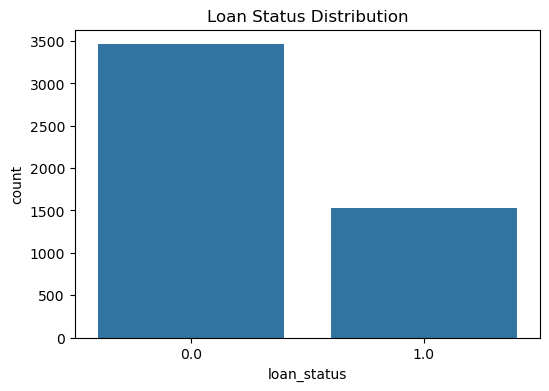

In [21]:
# Visualizing distribution of target variable that is loan_status

plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

Most borrowers belong to the non-default category that is (0) while fewer borrowers belong to the default category that is (1). This indicates that the dataset contains more successful loan repayments than defaults.

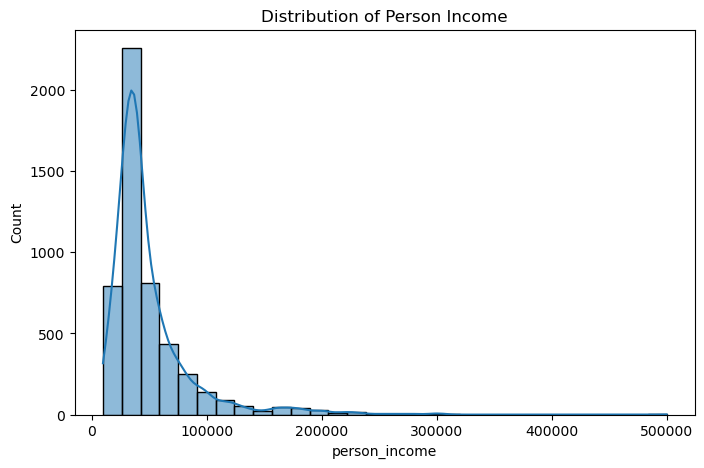

In [22]:
# Plotting histogram for person income

plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], bins=30, kde=True)
plt.title('Distribution of Person Income')
plt.show()

Income distribution appears to be right-skewed which indicating some borrowers have significantly higher incomes than others.

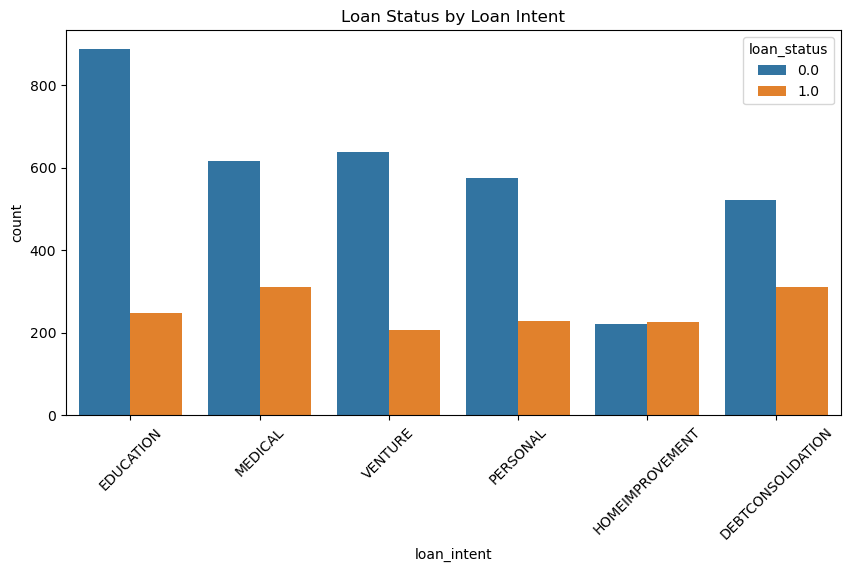

In [23]:
# Comparing loan status across loan purposes

plt.figure(figsize=(10,5))
sns.countplot(x='loan_intent',
              hue='loan_status',
              data=df)
plt.xticks(rotation=45)
plt.title('Loan Status by Loan Intent')
plt.show()

Borrowers applying for Education loans have the highest number of non-default cases while categories such as Medical and Debt Consolidation show comparatively higher default counts.

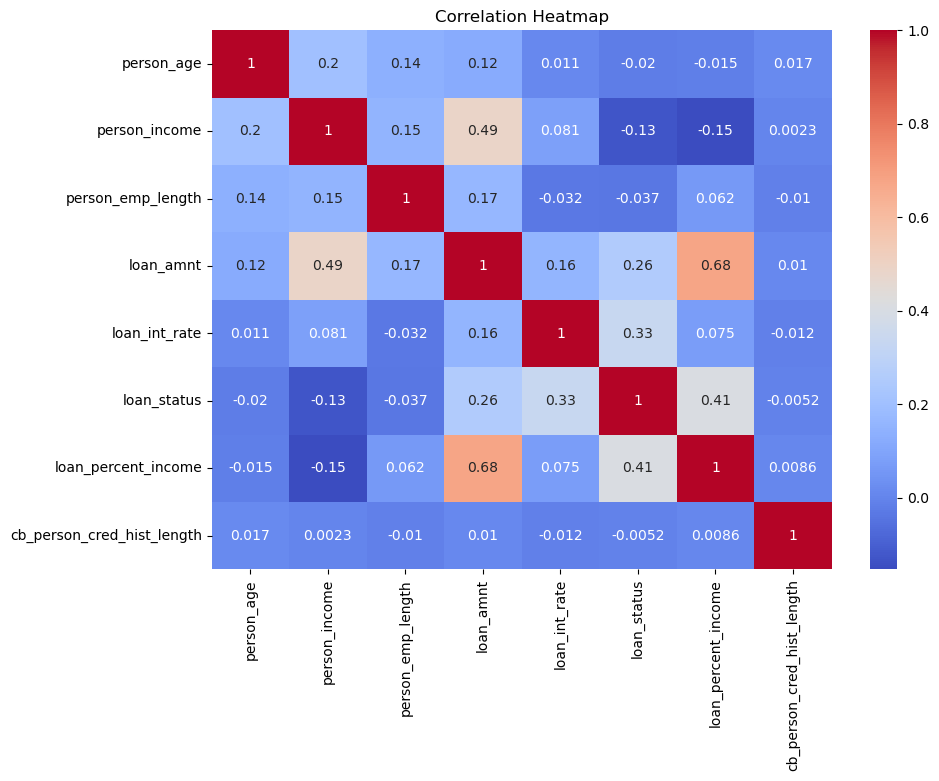

In [24]:
# Correlation matrix

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,7))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap indicates that some features such as loan_percent_income and loan_int_rate are more associated with loan status, while most other variables show weak correlations.

In [25]:
# Checking column datatypes

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4994 entries, 1 to 4999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  4994 non-null   float64
 1   person_income               4994 non-null   float64
 2   person_home_ownership       4994 non-null   object 
 3   person_emp_length           4994 non-null   float64
 4   loan_intent                 4994 non-null   object 
 5   loan_grade                  4994 non-null   object 
 6   loan_amnt                   4994 non-null   float64
 7   loan_int_rate               4994 non-null   float64
 8   loan_status                 4994 non-null   float64
 9   loan_percent_income         4994 non-null   float64
 10  cb_person_default_on_file   4994 non-null   object 
 11  cb_person_cred_hist_length  4994 non-null   float64
dtypes: float64(8), object(4)
memory usage: 507.2+ KB


In [26]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21.0,9600.0,OWN,5.0,EDUCATION,B,1000.0,11.14,0.0,0.10,N,2.0
2,25.0,9600.0,MORTGAGE,1.0,MEDICAL,C,5500.0,12.87,1.0,0.57,N,3.0
3,23.0,65500.0,RENT,4.0,MEDICAL,C,35000.0,15.23,1.0,0.53,N,2.0
4,24.0,54400.0,RENT,8.0,MEDICAL,C,35000.0,14.27,1.0,0.55,Y,4.0
5,21.0,9900.0,OWN,2.0,VENTURE,A,2500.0,7.14,1.0,0.25,N,2.0


In [27]:
# Reset dataframe index

df.reset_index(drop=True, inplace=True)

In [28]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21.0,9600.0,OWN,5.0,EDUCATION,B,1000.0,11.14,0.0,0.10,N,2.0
1,25.0,9600.0,MORTGAGE,1.0,MEDICAL,C,5500.0,12.87,1.0,0.57,N,3.0
2,23.0,65500.0,RENT,4.0,MEDICAL,C,35000.0,15.23,1.0,0.53,N,2.0
3,24.0,54400.0,RENT,8.0,MEDICAL,C,35000.0,14.27,1.0,0.55,Y,4.0
4,21.0,9900.0,OWN,2.0,VENTURE,A,2500.0,7.14,1.0,0.25,N,2.0


In [29]:
# FEATURE ENCODING :-

# Label Encoder object
# Used for ordinal and binary columns

le = LabelEncoder()

df['loan_grade'] = le.fit_transform(df['loan_grade'])

df['cb_person_default_on_file'] = le.fit_transform(
    df['cb_person_default_on_file']
)


# ONE HOT ENCODING
# Used for nominal categorical columns

df = pd.get_dummies(
    df,
    columns=['person_home_ownership',
             'loan_intent'],
    drop_first=True,
    dtype=int
)

df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,21.0,9600.0,5.0,1,1000.0,11.14,0.0,0.10,0,2.0,0,1,0,1,0,0,0,0
1,25.0,9600.0,1.0,2,5500.0,12.87,1.0,0.57,0,3.0,0,0,0,0,0,1,0,0
2,23.0,65500.0,4.0,2,35000.0,15.23,1.0,0.53,0,2.0,0,0,1,0,0,1,0,0
3,24.0,54400.0,8.0,2,35000.0,14.27,1.0,0.55,1,4.0,0,0,1,0,0,1,0,0
4,21.0,9900.0,2.0,0,2500.0,7.14,1.0,0.25,0,2.0,0,1,0,0,0,0,0,1


In [30]:

# FEATURE SELECTION :-

# Independent variables 

X = df.drop('loan_status', axis=1)

# Target variable

y = df['loan_status']

# Displaying shapes

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (4994, 17)
Target Shape : (4994,)


In [31]:
# TRAIN TEST SPLIT :-

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display dataset shapes

print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape : (3995, 17)
X_test Shape : (999, 17)
y_train Shape : (3995,)
y_test Shape : (999,)


In [32]:
# FEATURE SCALING :-

# scaler object

scaler = StandardScaler()

# training data

X_train_scaled = scaler.fit_transform(X_train)

# testing data

X_test_scaled = scaler.transform(X_test)

In [33]:
# SMOTE BALANCING :-

from imblearn.over_sampling import SMOTE

# Creating SMOTE object

smote = SMOTE(random_state=42)

# Applying SMOTE only on training data

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Checking balanced class distribution

print(y_train.value_counts())

print(y_train_smote.value_counts())

loan_status
0.0    2775
1.0    1220
Name: count, dtype: int64
loan_status
1.0    2775
0.0    2775
Name: count, dtype: int64


In [34]:
# LOGISTIC REGRESSION MODEL :-

# Creating Logistic Regression model

lr_model = LogisticRegression(random_state=42)

# Training model 

lr_model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
# MODEL PREDICTION

# Predicting loan status on testing dataset

y_pred_lr = lr_model.predict(X_test_scaled)

In [36]:
# Checking accuracy

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy Score :", lr_accuracy)

# classification report

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_lr))

Accuracy Score : 0.7947947947947948

Classification Report:

              precision    recall  f1-score   support

         0.0       0.89      0.80      0.84       687
         1.0       0.64      0.77      0.70       312

    accuracy                           0.79       999
   macro avg       0.76      0.79      0.77       999
weighted avg       0.81      0.79      0.80       999



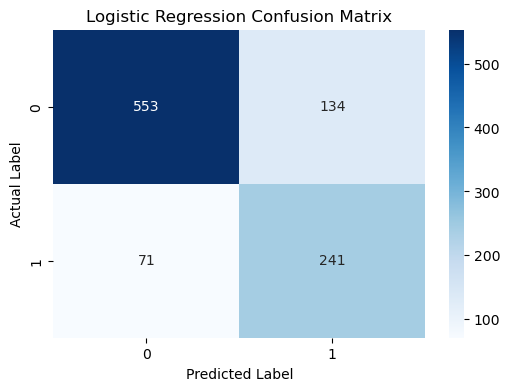

In [37]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted Label')

plt.ylabel('Actual Label')

plt.show()

In [38]:
# Calculating evaluation metrics

precision = precision_score(y_test, y_pred_lr)

recall = recall_score(y_test, y_pred_lr)

f1 = f1_score(y_test, y_pred_lr)

print("Precision Score :", precision)

print("Recall Score :", recall)

print("F1 Score :", f1)

Precision Score : 0.6426666666666667
Recall Score : 0.7724358974358975
F1 Score : 0.7016011644832606


In [39]:
# RANDOM FOREST MODEL :-

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training model 

rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
# MODEL PREDICTION

y_pred_rf = rf_model.predict(X_test_scaled)

In [41]:
# Checking accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy Score :", rf_accuracy)

# classification report

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))

Accuracy Score : 0.9179179179179179

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94       687
         1.0       0.92      0.81      0.86       312

    accuracy                           0.92       999
   macro avg       0.92      0.89      0.90       999
weighted avg       0.92      0.92      0.92       999



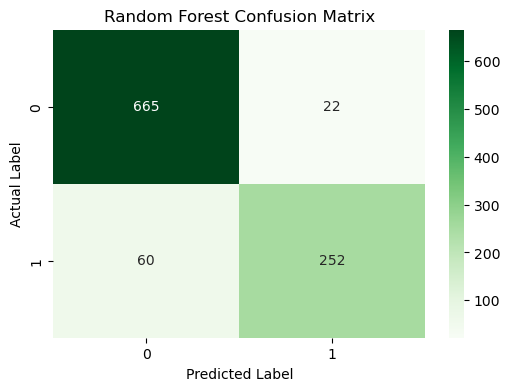

In [42]:
# confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)


plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted Label')

plt.ylabel('Actual Label')

plt.show()

In [43]:
# Calculating evaluation metrics

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

print("Precision Score :", rf_precision)

print("Recall Score :", rf_recall)

print("F1 Score :", rf_f1)

Precision Score : 0.9197080291970803
Recall Score : 0.8076923076923077
F1 Score : 0.8600682593856656


In [44]:
# DECISION TREE MODEL :-

dt_model = DecisionTreeClassifier(
    random_state=42
)

# Training model 

dt_model.fit(
    X_train_smote,
    y_train_smote
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
# MODEL PREDICTION

y_pred_dt = dt_model.predict(X_test_scaled)

In [46]:
# Checking accuracy score

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Accuracy Score :", dt_accuracy)

# classification report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

Accuracy Score : 0.8738738738738738

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.90      0.91       687
         1.0       0.79      0.82      0.80       312

    accuracy                           0.87       999
   macro avg       0.85      0.86      0.85       999
weighted avg       0.88      0.87      0.87       999



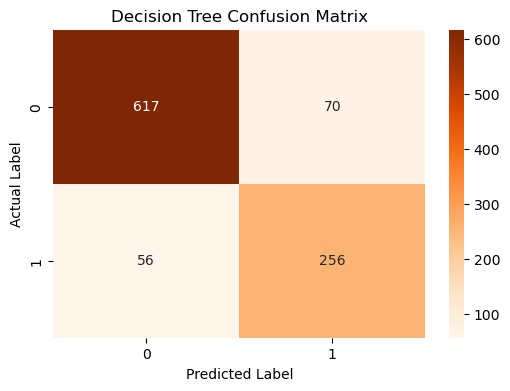

In [47]:
# confusion matrix

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title(
    'Decision Tree Confusion Matrix'
)

plt.xlabel('Predicted Label')

plt.ylabel('Actual Label')

plt.show()

In [48]:
# Displaying important features

feature_importance_dt = pd.DataFrame({

    'Feature': X.columns,
    'Importance': dt_model.feature_importances_

})

feature_importance_dt = feature_importance_dt.sort_values(
    by='Importance',
    ascending=False
)

print(
    feature_importance_dt.head(10)
)

                        Feature  Importance
6           loan_percent_income    0.257981
3                    loan_grade    0.200692
1                 person_income    0.189765
11   person_home_ownership_RENT    0.074452
0                    person_age    0.049366
5                 loan_int_rate    0.045886
2             person_emp_length    0.045536
4                     loan_amnt    0.029070
13  loan_intent_HOMEIMPROVEMENT    0.028117
12        loan_intent_EDUCATION    0.019877


In [49]:
# Calculating Precision, Recall and F1 Score

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

print("Precision Score :", dt_precision)

print("Recall Score :", dt_recall)

print("F1 Score :", dt_f1)

Precision Score : 0.7852760736196319
Recall Score : 0.8205128205128205
F1 Score : 0.8025078369905956


In [50]:
# XGBOOST MODEL :-

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Train model 

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [51]:
# MODEL PREDICTION

y_pred_xgb = xgb_model.predict(
    X_test_scaled
)

In [52]:
# Checking accuracy

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("Accuracy Score :", xgb_accuracy)

# classification report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

Accuracy Score : 0.908908908908909

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94       687
         1.0       0.89      0.80      0.85       312

    accuracy                           0.91       999
   macro avg       0.90      0.88      0.89       999
weighted avg       0.91      0.91      0.91       999



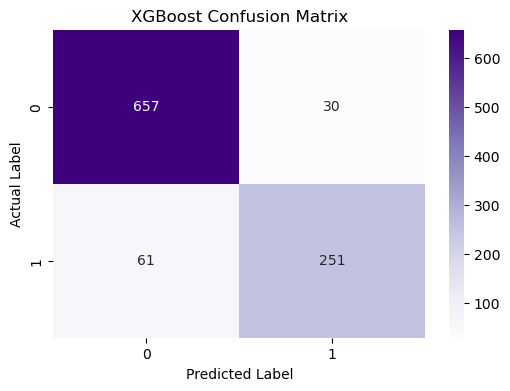

In [53]:
# confusion matrix

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title(
    'XGBoost Confusion Matrix'
)

plt.xlabel('Predicted Label')

plt.ylabel('Actual Label')

plt.show()

In [54]:
# Calculating evaluation metrics

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

print("Precision Score :", xgb_precision)

print("Recall Score :", xgb_recall)

print("F1 Score :", xgb_f1)

Precision Score : 0.8932384341637011
Recall Score : 0.8044871794871795
F1 Score : 0.8465430016863407


In [55]:
# Displaying XGBoost feature importance

feature_importance_xgb = pd.DataFrame({

    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_

})

# Sort importance values

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

print(
    feature_importance_xgb.head(10)
)

                        Feature  Importance
3                    loan_grade    0.193889
11   person_home_ownership_RENT    0.173468
6           loan_percent_income    0.119163
13  loan_intent_HOMEIMPROVEMENT    0.069590
16          loan_intent_VENTURE    0.066601
1                 person_income    0.053554
9   person_home_ownership_OTHER    0.050238
10    person_home_ownership_OWN    0.049744
12        loan_intent_EDUCATION    0.044245
0                    person_age    0.034406


In [56]:
# FEATURE IMPORTANCE COMPARISON :-

feature_comparison_2 = pd.DataFrame({

'Feature': X.columns,

'Logistic Regression':

abs(lr_model.coef_[0]),

'Decision Tree':

dt_model.feature_importances_,

'Random Forest':

rf_model.feature_importances_,

'XGBoost':

xgb_model.feature_importances_

})

# Sorted according to XGBoost importance

feature_comparison_2 = feature_comparison_2.sort_values(
    by='XGBoost',
    ascending=False
)

# top features

print(feature_comparison_2.head(15))

                        Feature  Logistic Regression  Decision Tree  \
3                    loan_grade             0.839777       0.200692   
11   person_home_ownership_RENT             0.837880       0.074452   
6           loan_percent_income             1.354149       0.257981   
13  loan_intent_HOMEIMPROVEMENT             0.343925       0.028117   
16          loan_intent_VENTURE             0.374469       0.014353   
1                 person_income             0.773334       0.189765   
9   person_home_ownership_OTHER             0.049268       0.002774   
10    person_home_ownership_OWN             0.133871       0.006243   
12        loan_intent_EDUCATION             0.410559       0.019877   
0                    person_age             0.130288       0.049366   
15         loan_intent_PERSONAL             0.193448       0.009657   
2             person_emp_length             0.046106       0.045536   
14          loan_intent_MEDICAL             0.072369       0.006651   
8    c

In this loan grade, loan percentage income, borrower income, home ownership status, and loan intent categories appeared as important predictors across multiple models. This suggests that borrower financial condition and credit quality strongly affect loan default prediction.

In [57]:
# MODEL COMPARISON TABLE :—

model_comparison_2 = pd.DataFrame({

'Model':[

'Logistic Regression',
'Decision Tree',
'Random Forest',
'XGBoost'

],

'Accuracy':[

lr_accuracy,
dt_accuracy,
rf_accuracy,
xgb_accuracy

],

'Precision':[

precision,
dt_precision,
rf_precision,
xgb_precision

],

'Recall':[

recall,
dt_recall,
rf_recall,
xgb_recall

],

'F1 Score':[

f1,
dt_f1,
rf_f1,
xgb_f1

]

})

print(model_comparison_2.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7948     0.6427  0.7724    0.7016
1        Decision Tree    0.8739     0.7853  0.8205    0.8025
2        Random Forest    0.9179     0.9197  0.8077    0.8601
3              XGBoost    0.9089     0.8932  0.8045    0.8465


In [58]:
# RANDOM FOREST HYPERPARAMETER TUNING

rf_params = {

'n_estimators':[100,200,300],

'max_depth':[10,20,30,None],

'min_samples_split':[2,5,10],

'min_samples_leaf':[1,2,4]

}

# Creating model

rf_tune = RandomForestClassifier(
    random_state=42
)

# Randomized Search

rf_random = RandomizedSearchCV(

estimator=rf_tune,

param_distributions=rf_params,

n_iter=10,

cv=5,

scoring='f1',

random_state=42,

n_jobs=-1

)

# Training model

rf_random.fit(
    X_train_smote,
    y_train_smote
)

# Best parameters

print("Best Parameters:")

print(rf_random.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [59]:
# Prediction

y_pred_rf_tuned = rf_random.predict(
    X_test_scaled
)

# Evaluation

print("Accuracy:",
      accuracy_score(y_test,y_pred_rf_tuned))

print(classification_report(
    y_test,
    y_pred_rf_tuned
))

Accuracy: 0.913913913913914
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94       687
         1.0       0.92      0.80      0.85       312

    accuracy                           0.91       999
   macro avg       0.91      0.88      0.90       999
weighted avg       0.91      0.91      0.91       999



In [60]:
# XGBOOST HYPERPARAMETER TUNING

xgb_params = {

'n_estimators':[100,200,300],

'max_depth':[3,5,7],

'learning_rate':[0.01,0.05,0.1],

'subsample':[0.8,1.0],

'colsample_bytree':[0.8,1.0]

}

# Creating Model

xgb_tune = XGBClassifier(

random_state=42,

eval_metric='logloss'

)

# Randomized Search

xgb_random = RandomizedSearchCV(

estimator=xgb_tune,

param_distributions=xgb_params,

n_iter=10,

cv=5,

scoring='f1',

random_state=42,

n_jobs=-1

)

# Training Model

xgb_random.fit(
    X_train_smote,
    y_train_smote
)

# Best Parameters

print("Best Parameters:")

print(xgb_random.best_params_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [61]:
# Prediction

y_pred_xgb_tuned = xgb_random.predict(
    X_test_scaled
)

# Evaluation

print("Accuracy:",
      accuracy_score(y_test,y_pred_xgb_tuned))

print(classification_report(
    y_test,
    y_pred_xgb_tuned
))

Accuracy: 0.918918918918919
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94       687
         1.0       0.93      0.80      0.86       312

    accuracy                           0.92       999
   macro avg       0.92      0.89      0.90       999
weighted avg       0.92      0.92      0.92       999



After hyperparameter tuning, both Random Forest and XGBoost showed strong performance. However, XGBoost performed slightly better with higher Accuracy, Precision, and F1 Score. Therefore, Tuned XGBoost was selected as the final model for loan default prediction.

In [62]:
# FINAL MODEL FEATURE IMPORTANCE

feature_importance_final = pd.DataFrame({

'Feature': X.columns,

'Importance':
rf_random.best_estimator_.feature_importances_

})

# Sort by importance

feature_importance_final = feature_importance_final.sort_values(
    by='Importance',
    ascending=False
)

# Display top features

print(feature_importance_final.head(10))

                        Feature  Importance
6           loan_percent_income    0.220088
1                 person_income    0.163157
3                    loan_grade    0.140106
5                 loan_int_rate    0.105418
4                     loan_amnt    0.103646
11   person_home_ownership_RENT    0.053964
2             person_emp_length    0.049989
0                    person_age    0.042502
13  loan_intent_HOMEIMPROVEMENT    0.028580
8    cb_person_cred_hist_length    0.023295


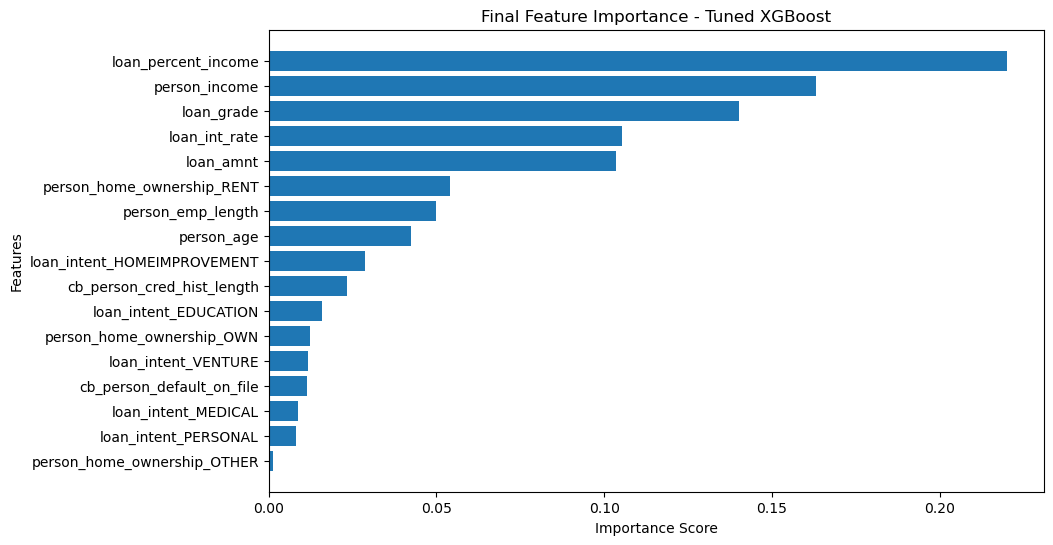

In [63]:
# HORIZONTAL BAR CHART — FINAL FEATURE IMPORTANCE ACCORDING TO XGBOOST

feature_importance_final = feature_importance_final.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_final['Feature'],
    feature_importance_final['Importance']
)

plt.title('Final Feature Importance - Tuned XGBoost')

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.show()

# Final Conclusion

In this project, different machine learning models such as Logistic Regression, Decision Tree, Random Forest, and XGBoost were used to predict loan default. Before building the models, preprocessing steps like handling missing values, encoding, feature scaling, train-test split, and SMOTE were applied.

The models were compared using Accuracy, Precision, Recall, and F1 Score. After model comparison and hyperparameter tuning, XGBoost achieved the best performance with about 91.9% Accuracy, 93% Precision, 80% Recall, and 0.86 F1 Score.

Feature importance analysis showed that loan percentage income, person income, loan grade, loan interest rate, loan amount, and home ownership status were among the most important factors influencing loan default prediction.

Therefore, Tuned XGBoost was selected as the final model because it provided the most balanced prediction performance among all the models.

This project shows how machine learning can be used to predict loan default and support better loan risk assessment and decision-making.
